# Aula 11 — Iterated Local Search (ILS) para o CVRP da Prolog

Este notebook aplica a metaheurística Iterated Local Search sobre as soluções pós-busca-local geradas na Aula 8 e quantifica o ganho operacional obtido em relação à busca local standalone (Baseline 1) para as quatro instâncias C1–C4 do projeto.

A pergunta central da Sprint 3 é direta: a perturbação do ILS consegue escapar dos ótimos locais da Sprint 2 com ganho de custo relevante para a operação da Prolog? Em quais instâncias o esforço extra se paga, e em quais a busca local standalone já basta?

O grupo opera na configuração **Equipe 2** definida pelo professor no Sprint Planning #3 (Aula 11A, slide 8): perturbação **double-bridge** com critério de aceitação **estrito**. A busca local intra-ILS fica fixada em 2-opt + Relocate (mesma da Aula 8) para garantir comparação justa com as demais equipes da turma. O design experimental segue o protocolo da Tarefa 10: o ILS é executado em duas trilhas de solução inicial — Nearest Neighbor + busca local e Clarke-Wright + busca local — para que possamos comparar não só o ganho percentual mas também a qualidade final absoluta entregue por cada ponto de partida.

## 1. Preparação do ambiente

Definimos os caminhos relativos para as instâncias C1–C4 (geradas na Aula 2) e para as soluções pós-busca-local (geradas na Aula 8). As pastas `files/` e `images/` do diretório atual recebem os artefatos produzidos por esta aula.

In [1]:
import copy
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASETS_DIR = Path("../../2/datasets")
SOLUTIONS_BL_DIR = Path("../../8/Aula8_Busca_Local/files")
OUTPUT_FILES_DIR = Path("files")
OUTPUT_FILES_DIR.mkdir(exist_ok=True)
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

INSTANCIAS = {
    "C1": "Equipe_2_C1_10",
    "C2": "Equipe_2_C2_25",
    "C3": "Equipe_2_C3_40",
    "C4": "Equipe_2_C4_60",
}
HEURISTICAS = ["NN", "CW"]

assert DATASETS_DIR.exists(), f"Diretório de instâncias não encontrado: {DATASETS_DIR.resolve()}"
assert SOLUTIONS_BL_DIR.exists(), f"Diretório de soluções pós-BL não encontrado: {SOLUTIONS_BL_DIR.resolve()}"

print("Datasets (Aula 2):       ", DATASETS_DIR.resolve())
print("Soluções pós-BL (Aula 8):", SOLUTIONS_BL_DIR.resolve())
print("Instâncias:", list(INSTANCIAS.keys()))
print("Heurísticas iniciais:", HEURISTICAS)

Datasets (Aula 2):        C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\2\datasets
Soluções pós-BL (Aula 8): C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\8\Aula8_Busca_Local\files
Instâncias: ['C1', 'C2', 'C3', 'C4']
Heurísticas iniciais: ['NN', 'CW']


## 2. Carregamento das instâncias C1–C4

Reaproveitamos a função `load_instance` das Aulas 7 e 8. As instâncias carregadas aqui são exatamente as mesmas usadas em toda a Sprint 2, o que garante que qualquer diferença observada nos custos seja atribuível exclusivamente ao ILS e não a mudanças nos dados de entrada.

In [2]:
def load_instance(name):
    folder = DATASETS_DIR / INSTANCIAS[name]
    nodes = pd.read_csv(folder / "nodes.csv")
    D = np.load(folder / "D.npy")
    q = np.load(folder / "q.npy")
    s = np.load(folder / "s.npy")
    params_raw = json.loads((folder / "params.json").read_text(encoding="utf-8"))

    n = len(nodes)
    assert D.shape == (n, n), f"Dimensão incorreta de D em {name}"
    assert q.shape == (n,), f"Dimensão incorreta de q em {name}"
    assert s.shape == (n,), f"Dimensão incorreta de s em {name}"
    assert nodes.loc[0, "id"] == 0, f"Depósito deve ter id = 0 em {name}"

    return {
        "name": name,
        "n_clientes": n - 1,
        "nodes": nodes,
        "D": D,
        "q": q,
        "s": s,
        "params_raw": params_raw,
    }


INST = {name: load_instance(name) for name in INSTANCIAS}

for name, inst in INST.items():
    print(f"{name}: {inst['n_clientes']} clientes + depósito | "
          f"demanda total = {inst['q'][1:].sum():.2f} kg | "
          f"maior demanda = {inst['q'][1:].max():.2f} kg")

C1: 10 clientes + depósito | demanda total = 141.56 kg | maior demanda = 52.95 kg
C2: 25 clientes + depósito | demanda total = 754.48 kg | maior demanda = 129.25 kg
C3: 40 clientes + depósito | demanda total = 1295.25 kg | maior demanda = 153.56 kg
C4: 60 clientes + depósito | demanda total = 1958.12 kg | maior demanda = 206.05 kg


As quatro instâncias carregaram com o mesmo perfil das Aulas 7 e 8 — 10, 25, 40 e 60 clientes, demanda total crescendo de 141,56 kg a 1.958,12 kg, maior demanda individual de 206,05 kg em C4 (abaixo dos 650 kg do Fiorino). Nenhum cliente isolado força o uso do VUC por capacidade.

## 3. Parâmetros logísticos

Mantemos a especificação operacional das Aulas 4, 7 e 8: Fiorino (FIO) com 650 kg de capacidade e R$ 250 de custo fixo diário, VUC com 3.000 kg e R$ 550, custo variável uniforme de R$ 1,50/km, velocidade média de 40 km/h e jornada máxima de 8 horas. O atendimento por cliente é de 15 minutos. O código do professor (Seção 4 do `eng4560_aula_11_ils.py`) consolida tudo num único dicionário `params` que é passado adiante para todas as funções de rota.

In [3]:
params = {
    "capacity":    {"FIO": 650.0,  "VUC": 3000.0},
    "fixed_cost":  {"FIO": 250.0,  "VUC": 550.0},
    "cost_per_km": 1.50,
    "speed_kmh":   40.0,
    "max_hours":   8.0,
}

print("Parâmetros operacionais:")
for k, v in params.items():
    print(f"  {k}: {v}")

# Verificação da unidade de s. O notebook do professor assume horas;
# nos arquivos da Aula 2 o vetor pode estar em minutos. Inspecionamos C1.
s_c1 = INST["C1"]["s"]
print(f"\ns (C1): mínimo (sem depósito) = {s_c1[1:].min()}, máximo = {s_c1[1:].max()}")
print("(15 min = 0.25 h; se o valor estiver em torno de 15, está em minutos)")

Parâmetros operacionais:
  capacity: {'FIO': 650.0, 'VUC': 3000.0}
  fixed_cost: {'FIO': 250.0, 'VUC': 550.0}
  cost_per_km: 1.5
  speed_kmh: 40.0
  max_hours: 8.0

s (C1): mínimo (sem depósito) = 0.25, máximo = 0.25
(15 min = 0.25 h; se o valor estiver em torno de 15, está em minutos)


Os tempos de atendimento `s` já vêm em horas (0,25 h = 15 min por cliente em todas as instâncias). Não precisamos da conversão `s/60` que o template do professor menciona como precaução para arquivos em minutos.

## 4. Carregamento das oito soluções pós-busca-local (Sprint 2)

A Aula 8 produziu oito JSONs em `Aulas/8/Aula8_Busca_Local/files/`: para cada instância C1–C4, uma solução pós-busca-local com semente Nearest Neighbor (`nn`) e outra com semente Clarke-Wright (`cw`). Essas oito soluções são os pontos de partida que alimentarão tanto o Baseline 1 (busca local standalone re-aplicada) quanto o ILS.

Carregar as duas trilhas — NN e CW — é o que viabiliza a Tarefa 10 do Sprint Planning #3: comparar não só ganho percentual mas também qualidade final absoluta de cada origem.

In [4]:
def normalize_vehicle(v):
    v = str(v).upper()
    if v in ("FIO", "FIORINO"):
        return "FIO"
    if v == "VUC":
        return "VUC"
    raise ValueError(f"Tipo de veículo desconhecido: {v}")


def normalize_solution(sol):
    return [
        {
            "route_id": item.get("route_id", idx + 1),
            "vehicle":  normalize_vehicle(item["vehicle"]),
            "route":    item["route"],
        }
        for idx, item in enumerate(sol)
    ]


def load_initial_solution(heuristic, instance):
    path = SOLUTIONS_BL_DIR / f"solution_busca_local_{heuristic.lower()}_{instance}.json"
    payload = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(payload, dict) and "solution" in payload:
        sol = payload["solution"]
    else:
        sol = payload
    return normalize_solution(sol)


INITIAL_SOLUTIONS = {
    heuristic: {inst: load_initial_solution(heuristic, inst) for inst in INSTANCIAS}
    for heuristic in HEURISTICAS
}

print("Soluções iniciais carregadas:")
for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        sol = INITIAL_SOLUTIONS[heuristic][inst]
        n_clientes = sum(1 for item in sol for node in item["route"] if node != 0)
        veiculos = [item["vehicle"] for item in sol]
        print(f"  {heuristic:>2} {inst}: {len(sol)} rotas | "
              f"{n_clientes} clientes | veículos {veiculos}")

Soluções iniciais carregadas:
  NN C1: 1 rotas | 10 clientes | veículos ['FIO']
  NN C2: 2 rotas | 25 clientes | veículos ['FIO', 'FIO']
  NN C3: 3 rotas | 40 clientes | veículos ['FIO', 'FIO', 'FIO']
  NN C4: 4 rotas | 60 clientes | veículos ['FIO', 'FIO', 'FIO', 'FIO']
  CW C1: 1 rotas | 10 clientes | veículos ['FIO']
  CW C2: 2 rotas | 25 clientes | veículos ['FIO', 'FIO']
  CW C3: 2 rotas | 40 clientes | veículos ['VUC', 'FIO']
  CW C4: 3 rotas | 60 clientes | veículos ['FIO', 'FIO', 'VUC']


As oito soluções carregaram com a estrutura esperada das Aulas 7 e 8. A composição de frota já difere entre as trilhas a olho nu: o NN distribui tudo em Fiorinos (1, 2, 3 e 4 rotas) e o CW recorre ao VUC para consolidar clientes em C3 e C4. Essa diferença estrutural é o que torna a Tarefa 10 interessante — o ILS partirá de pontos com perfis de frota diferentes, e a comparação dirá se a vantagem teórica do CW (rotas mais bem desenhadas) se mantém após a metaheurística ou se o NN é capaz de alcançá-lo via diversificação.

## 5. Seed e reprodutibilidade

Conforme o protocolo da Aula 11 (slide 22): seed fixa, mesma instância, mesma solução inicial. Sem isso, qualquer comparação entre equipes seria estatisticamente sem sentido.

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f"Seed fixada: {SEED}")

Seed fixada: 42


## 6. Funções de rota, viabilidade e métricas

O bloco abaixo replica literalmente as funções de rota da Seção 3 do template do professor (`eng4560_aula_11_ils.py`, Aula 11). São as mesmas usadas nas Aulas 7 e 8 — preservadas verbatim para garantir que a composição com o ILS seja idêntica ao que será aceito pelo professor.

In [6]:
def route_distance(route, D):
    """Distância total percorrida na rota (km), incluindo retorno ao depósito."""
    return sum(D[route[i], route[i+1]] for i in range(len(route)-1))


def route_load(route, q):
    """Carga total transportada (kg). Exclui o depósito (nó 0)."""
    return sum(q[node] for node in route if node != 0)


def route_service_time(route, s):
    """Tempo total de atendimento (horas). Exclui o depósito (nó 0)."""
    return sum(s[node] for node in route if node != 0)


def route_total_time(route, D, s, v_kmh):
    """Tempo total da rota (h) = deslocamento + serviço. Retorna (t_total, t_mov, t_serv)."""
    t_mov  = route_distance(route, D) / v_kmh
    t_serv = route_service_time(route, s)
    return t_mov + t_serv, t_mov, t_serv


def route_cost(route, vehicle_type, D, params):
    """Custo total da rota (R$) = custo fixo + custo variável por km."""
    clientes = [node for node in route if node != 0]
    if not clientes:
        return 0.0
    dist  = route_distance(route, D)
    fixed = params["fixed_cost"][vehicle_type]
    var   = params["cost_per_km"]
    return fixed + var * dist


def is_route_feasible(route, vehicle_type, D, q, s, params):
    """Verifica capacidade do veículo e jornada máxima."""
    load_ok = route_load(route, q) <= params["capacity"][vehicle_type] + 1e-6
    t_total, _, _ = route_total_time(route, D, s, params["speed_kmh"])
    time_ok = t_total <= params["max_hours"] + 1e-6
    return load_ok and time_ok


def is_solution_feasible(solution, D, q, s, params):
    """Solução é viável se cobre todos os clientes uma vez e todas as rotas são viáveis."""
    visited = []
    for item in solution:
        if not is_route_feasible(item["route"], item["vehicle"], D, q, s, params):
            return False
        visited.extend(node for node in item["route"] if node != 0)
    expected = list(range(1, len(q)))
    return sorted(visited) == expected


def total_solution_cost(solution, D, params):
    """Soma dos custos de todas as rotas (R$)."""
    return sum(route_cost(item["route"], item["vehicle"], D, params)
               for item in solution)


def solution_metrics(solution, D, q, s, params):
    """Métricas consolidadas da solução."""
    n_fio = n_vuc = 0
    total_dist = total_cost = total_time = 0.0
    cap_viol = time_viol = 0
    for item in solution:
        route, veh = item["route"], item["vehicle"]
        dist  = route_distance(route, D)
        cost  = route_cost(route, veh, D, params)
        t, _, _ = route_total_time(route, D, s, params["speed_kmh"])
        total_dist += dist
        total_cost += cost
        total_time += t
        if veh == "FIO": n_fio += 1
        else:            n_vuc += 1
        if route_load(route, q) > params["capacity"][veh] + 1e-6:
            cap_viol += 1
        if t > params["max_hours"] + 1e-6:
            time_viol += 1
    return {
        "n_routes":            len(solution),
        "n_fio":               n_fio,
        "n_vuc":               n_vuc,
        "total_distance_km":   round(total_dist, 2),
        "total_cost_rs":       round(total_cost, 2),
        "total_time_h":        round(total_time, 2),
        "capacity_violations": cap_viol,
        "time_violations":     time_viol,
    }


print("Funções de rota, viabilidade e métricas definidas.")

Funções de rota, viabilidade e métricas definidas.


Verificamos abaixo se as oito soluções pós-busca-local da Sprint 2 ainda são viáveis sob essas funções — qualquer divergência indicaria inconsistência entre os dados da Aula 2 e os JSONs salvos na Aula 8.

In [7]:
rows = []
for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        sol = INITIAL_SOLUTIONS[heuristic][inst]
        D, q, s = INST[inst]["D"], INST[inst]["q"], INST[inst]["s"]
        viavel = is_solution_feasible(sol, D, q, s, params)
        custo  = total_solution_cost(sol, D, params)
        m = solution_metrics(sol, D, q, s, params)
        rows.append({
            "heurística": heuristic,
            "instância":  inst,
            "viável":     viavel,
            "n_rotas":    m["n_routes"],
            "fio/vuc":    f"{m['n_fio']}/{m['n_vuc']}",
            "dist_km":    m["total_distance_km"],
            "custo_rs":   m["total_cost_rs"],
            "viol_cap":   m["capacity_violations"],
            "viol_temp":  m["time_violations"],
        })

df_iniciais = pd.DataFrame(rows)
display(df_iniciais)

,heurística,instância,viável,n_rotas,fio/vuc,dist_km,custo_rs,viol_cap,viol_temp
0,NN,C1,True,1,1/0,114.92,422.38,0,0
1,NN,C2,True,2,2/0,141.66,712.49,0,0
2,NN,C3,True,3,3/0,195.79,1043.69,0,0
3,NN,C4,True,4,4/0,273.33,1410.00,0,0
4,CW,C1,True,1,1/0,114.92,422.38,0,0
5,CW,C2,True,2,2/0,141.37,712.05,0,0
6,CW,C3,True,2,1/1,165.33,1047.99,0,0
7,CW,C4,True,3,2/1,240.14,1410.21,0,0


Todas as oito soluções permanecem viáveis sem nenhuma violação de capacidade ou jornada. Os custos batem com os reportados no README da Aula 8: NN-C1=422,38, NN-C2=712,49, NN-C3=1.043,69, NN-C4=1.410,00, CW-C1=422,38, CW-C2=712,05, CW-C3=1.047,99 e CW-C4=1.410,21. A diferença NN×CW por instância é mínima (≤ 0,5% em C1–C4), mas o CW economiza uma rota em C3 e em C4 ao mover demanda consolidada para o VUC. O ILS herdará esses dois perfis e precisará decidir se vale a pena reorganizar a frota.

## 7. Movimentos de busca local: 2-opt, Relocate e Swap

A busca local intra-ILS usa os mesmos três movimentos da Aula 8, encapsulados conforme o template do professor (Seção 4 do `eng4560_aula_11_ils.py`). A composição na Sprint 3 fica fixada em **2-opt + Relocate** (slide 14 da Aula 11): o Swap é o operador mais caro e o experimento controlado mantém todas as equipes na mesma vizinhança.

In [8]:
def two_opt_swap(route, i, k):
    """Aplica um movimento 2-opt: inverte route[i:k+1]."""
    return route[:i] + route[i:k+1][::-1] + route[k+1:]


def improve_route_2opt(route, vehicle_type, D, q, s, params):
    """2-opt exaustivo (first improvement) em uma única rota."""
    best_route = route[:]
    best_dist  = route_distance(best_route, D)
    improved   = True
    while improved:
        improved = False
        for i in range(1, len(best_route) - 2):
            for k in range(i + 1, len(best_route) - 1):
                candidate = two_opt_swap(best_route, i, k)
                if not is_route_feasible(candidate, vehicle_type, D, q, s, params):
                    continue
                cand_dist = route_distance(candidate, D)
                if cand_dist < best_dist - 1e-6:
                    best_route = candidate
                    best_dist  = cand_dist
                    improved   = True
                    break
            if improved:
                break
    return best_route


def apply_2opt(solution, D, q, s, params):
    """Aplica improve_route_2opt a cada rota da solução."""
    return [
        {**item, "route": improve_route_2opt(
            item["route"], item["vehicle"], D, q, s, params)}
        for item in solution
    ]


def relocate_customer(route_from, route_to, idx_from, idx_to):
    """Move cliente de idx_from em route_from para idx_to em route_to."""
    new_from = route_from[:]
    new_to   = route_to[:]
    customer = new_from.pop(idx_from)
    new_to.insert(idx_to, customer)
    return new_from, new_to


def apply_relocate(solution, D, q, s, params):
    """Relocate first-improvement entre todos os pares de rotas."""
    best      = copy.deepcopy(solution)
    best_cost = total_solution_cost(best, D, params)
    improved  = True
    while improved:
        improved = False
        for a in range(len(best)):
            if improved: break
            for b in range(len(best)):
                if improved or a == b: break
                r_from, r_to = best[a]["route"], best[b]["route"]
                for idx_from in range(1, len(r_from) - 1):
                    if improved: break
                    for idx_to in range(1, len(r_to)):
                        cand = copy.deepcopy(best)
                        nf, nt = relocate_customer(
                            cand[a]["route"], cand[b]["route"],
                            idx_from, idx_to)
                        cand[a]["route"] = nf
                        cand[b]["route"] = nt
                        cand = [item for item in cand
                                if any(node != 0 for node in item["route"])]
                        for rid, item in enumerate(cand, 1):
                            item["route_id"] = rid
                        if not is_solution_feasible(cand, D, q, s, params):
                            continue
                        cand_cost = total_solution_cost(cand, D, params)
                        if cand_cost < best_cost - 1e-6:
                            best, best_cost = cand, cand_cost
                            improved = True
                            break
    return best


def swap_customers(route_a, route_b, idx_a, idx_b):
    """Troca clientes em idx_a de route_a com idx_b de route_b."""
    new_a, new_b = route_a[:], route_b[:]
    new_a[idx_a], new_b[idx_b] = new_b[idx_b], new_a[idx_a]
    return new_a, new_b


def apply_swap(solution, D, q, s, params):
    """Swap first-improvement entre pares de rotas distintas."""
    best      = copy.deepcopy(solution)
    best_cost = total_solution_cost(best, D, params)
    improved  = True
    while improved:
        improved = False
        for a in range(len(best)):
            if improved: break
            for b in range(a + 1, len(best)):
                if improved: break
                r_a, r_b = best[a]["route"], best[b]["route"]
                for ia in range(1, len(r_a) - 1):
                    if improved: break
                    for ib in range(1, len(r_b) - 1):
                        cand = copy.deepcopy(best)
                        na, nb = swap_customers(
                            cand[a]["route"], cand[b]["route"], ia, ib)
                        cand[a]["route"] = na
                        cand[b]["route"] = nb
                        if not is_solution_feasible(cand, D, q, s, params):
                            continue
                        cand_cost = total_solution_cost(cand, D, params)
                        if cand_cost < best_cost - 1e-6:
                            best, best_cost = cand, cand_cost
                            improved = True
                            break
    return best


def local_search(solution, D, q, s, params,
                 use_2opt=True, use_relocate=True, use_swap=False):
    """Busca local composta. Por padrão na Sprint 3: 2-opt + Relocate (slide 14 da Aula 11)."""
    current = copy.deepcopy(solution)
    if use_2opt:
        current = apply_2opt(current, D, q, s, params)
    if use_relocate:
        current = apply_relocate(current, D, q, s, params)
    if use_swap:
        current = apply_swap(current, D, q, s, params)
    return current


print("Movimentos de busca local e busca local composta definidos.")

Movimentos de busca local e busca local composta definidos.


## 8. Perturbações P1, P2 e P3

As três perturbações da Aula 11 são implementadas conforme as Seções 7 do template do professor. Mantemos a P2 (Swap aleatório) ainda que a configuração da Equipe 2 use apenas P3 — a manutenção das três variantes preserva a integridade do código de referência e permite, na Seção 13 (Tarefa 12, instância secreta), experimentar combinações livres sem reescrever funções.

A perturbação central da Equipe 2 é a **double-bridge** (P3). Sua propriedade-chave (slide 16): a reconexão `seg1 + seg3 + seg2 + seg4` produz uma sequência que nenhum movimento 2-opt consegue desfazer, garantindo que a busca local subsequente parta de uma bacia de atração genuinamente diferente.

In [9]:
def perturb_relocate_random(solution, D, q, s, params, rng):
    """P1 — Move um cliente aleatório para rota/posição aleatórias.
    Retorna a solução perturbada se viável, ou a original se não."""
    candidate = copy.deepcopy(solution)
    src_candidates = [idx for idx, item in enumerate(candidate)
                      if len(item["route"]) > 3]
    if not src_candidates:
        return candidate
    a = rng.choice(src_candidates)
    b = rng.randint(0, len(candidate) - 1)
    r_from = candidate[a]["route"]
    r_to   = candidate[b]["route"]
    if len(r_from) <= 2:
        return candidate
    idx_from = rng.randint(1, len(r_from) - 2)
    idx_to   = rng.randint(1, len(r_to) - 1)
    new_from, new_to = relocate_customer(r_from, r_to, idx_from, idx_to)
    candidate[a]["route"] = new_from
    candidate[b]["route"] = new_to
    candidate = [item for item in candidate
                 if any(node != 0 for node in item["route"])]
    for rid, item in enumerate(candidate, 1):
        item["route_id"] = rid
    if is_solution_feasible(candidate, D, q, s, params):
        return candidate
    return copy.deepcopy(solution)


def perturb_swap_random(solution, D, q, s, params, rng):
    """P2 — Troca dois clientes aleatórios entre rotas distintas."""
    candidate = copy.deepcopy(solution)
    valid = [idx for idx, item in enumerate(candidate)
             if len(item["route"]) > 3]
    if len(valid) < 2:
        return candidate
    a, b = rng.sample(valid, 2)
    r_a = candidate[a]["route"]
    r_b = candidate[b]["route"]
    idx_a = rng.randint(1, len(r_a) - 2)
    idx_b = rng.randint(1, len(r_b) - 2)
    new_a, new_b = swap_customers(r_a, r_b, idx_a, idx_b)
    candidate[a]["route"] = new_a
    candidate[b]["route"] = new_b
    if is_solution_feasible(candidate, D, q, s, params):
        return candidate
    return copy.deepcopy(solution)


def perturb_double_bridge(solution, D, q, s, params, rng):
    """P3 — Double-bridge intra-rota: seg1 + seg3 + seg2 + seg4."""
    candidate = copy.deepcopy(solution)
    valid = [idx for idx, item in enumerate(candidate)
             if len(item["route"]) >= 6]
    if not valid:
        return perturb_relocate_random(solution, D, q, s, params, rng)
    r_idx   = rng.choice(valid)
    route   = candidate[r_idx]["route"]
    clients = route[1:-1]
    n = len(clients)
    if n < 4:
        return perturb_relocate_random(solution, D, q, s, params, rng)
    cuts = sorted(rng.sample(range(1, n), 3))
    a, b, c = cuts
    seg1, seg2, seg3, seg4 = clients[:a], clients[a:b], clients[b:c], clients[c:]
    new_route = [0] + seg1 + seg3 + seg2 + seg4 + [0]
    candidate[r_idx]["route"] = new_route
    if is_solution_feasible(candidate, D, q, s, params):
        return candidate
    return copy.deepcopy(solution)


def perturb_solution(solution, D, q, s, params, rng,
                     perturbation_type, perturbation_k=1):
    """Dispatcher de perturbações. Implementação dos três TODOs do template."""
    if perturbation_type == 'relocate_random':
        result = copy.deepcopy(solution)
        for _ in range(perturbation_k):
            result = perturb_relocate_random(result, D, q, s, params, rng)
        return result

    elif perturbation_type == 'swap_random':
        result = copy.deepcopy(solution)
        for _ in range(perturbation_k):
            result = perturb_swap_random(result, D, q, s, params, rng)
        return result

    elif perturbation_type == 'double_bridge':
        return perturb_double_bridge(solution, D, q, s, params, rng)

    else:
        raise ValueError(
            f"Perturbação desconhecida: '{perturbation_type}'. "
            f"Opções: 'relocate_random', 'swap_random', 'double_bridge'."
        )


print("Perturbações P1, P2, P3 e dispatcher definidos.")

Perturbações P1, P2, P3 e dispatcher definidos.


## 9. Critério de aceitação e laço principal do ILS

O critério de aceitação determina o que é a "solução corrente" da próxima iteração. A Equipe 2 opera com aceitação **estrita** (slide 21 da Aula 11): só substitui a corrente se o candidato superar estritamente o custo dela. Mantemos a opção `tolerance` no código para permitir experimentação na seção da instância secreta.

O laço principal segue o fluxo da Aula 11 (slide 12) — solução inicial → busca local → ótimo local *S\** → perturbação → busca local → *S''\** → aceitação → atualização da melhor global. A atualização da melhor global é **independente** da aceitação (slide 18): um candidato pode estabelecer novo recorde mesmo sem ser aceito como corrente.

In [10]:
def accept_solution(cost_new, cost_current, criterion, tolerance_pct=0.03):
    """Critério de aceitação do ILS — slide 17 da Aula 11."""
    if criterion == 'strict':
        return cost_new < cost_current - 1e-6
    elif criterion == 'tolerance':
        threshold = cost_current * (1.0 + tolerance_pct)
        return cost_new <= threshold
    else:
        raise ValueError(f"Critério inválido: '{criterion}'. Use 'strict' ou 'tolerance'.")


def iterated_local_search(
    initial_solution,
    D, q, s, params,
    perturbation_type="double_bridge",
    perturbation_k=1,
    use_2opt=True,
    use_relocate=True,
    use_swap=False,
    accept_criterion="strict",
    tolerance_pct=0.0,
    n_iterations=100,
    time_limit_sec=None,
    seed=42,
    verbose=False,
):
    """Iterated Local Search seguindo o template da Aula 11.
    Retorna (best_solution, history)."""
    rng = random.Random(seed)
    start_time = time.time()

    current_solution = local_search(initial_solution, D, q, s, params,
                                    use_2opt, use_relocate, use_swap)
    current_cost = total_solution_cost(current_solution, D, params)
    best_solution = copy.deepcopy(current_solution)
    best_cost     = current_cost

    history = [{
        "iteration":    0,
        "current_cost": current_cost,
        "best_cost":    best_cost,
        "elapsed_sec":  0.0,
        "accepted":     True,
    }]

    if verbose:
        print(f"{'Iter':>5} | {'Custo atual':>12} | {'Melhor':>12} | Aceito")
        print("-" * 50)
        print(f"{'0':>5} | R$ {current_cost:>9.2f} | R$ {best_cost:>9.2f} |  init")

    for it in range(1, n_iterations + 1):
        elapsed = time.time() - start_time
        if time_limit_sec is not None and elapsed >= time_limit_sec:
            if verbose:
                print(f"Limite de tempo atingido ({elapsed:.1f}s) após {it-1} iterações.")
            break

        perturbed = perturb_solution(current_solution, D, q, s, params, rng,
                                     perturbation_type=perturbation_type,
                                     perturbation_k=perturbation_k)
        candidate      = local_search(perturbed, D, q, s, params,
                                      use_2opt, use_relocate, use_swap)
        candidate_cost = total_solution_cost(candidate, D, params)

        accepted = accept_solution(candidate_cost, current_cost,
                                   accept_criterion, tolerance_pct)
        if accepted:
            current_solution = copy.deepcopy(candidate)
            current_cost     = candidate_cost

        if candidate_cost < best_cost - 1e-6:
            best_solution = copy.deepcopy(candidate)
            best_cost     = candidate_cost

        history.append({
            "iteration":    it,
            "current_cost": current_cost,
            "best_cost":    best_cost,
            "elapsed_sec":  time.time() - start_time,
            "accepted":     accepted,
        })

        if verbose and (it <= 5 or it % 10 == 0):
            status = "+" if accepted else "-"
            print(f"{it:>5} | R$ {current_cost:>9.2f} | R$ {best_cost:>9.2f} |  {status}")

    if verbose:
        ganho = (history[0]["current_cost"] - best_cost) / history[0]["current_cost"] * 100
        print("-" * 50)
        print(f"Concluído em {time.time()-start_time:.1f}s | "
              f"Melhor: R$ {best_cost:.2f} | Ganho vs BL inicial: {ganho:.2f}%")

    return best_solution, history


print("accept_solution e iterated_local_search definidos.")

accept_solution e iterated_local_search definidos.


## 10. Configuração da Equipe 2

A Tarefa 1 do Sprint Planning #3 exige o registro explícito da configuração experimental. A Equipe 2 (3VA e 3VB) opera com perturbação **double-bridge** e aceitação **estrita** — uma combinação que aposta na propriedade não-reversível do P3 para gerar diversificação sem precisar tolerar pioras na solução corrente.

In [11]:
CONFIG_EQUIPE2 = {
    "perturbation_type": "double_bridge",
    "perturbation_k":    1,
    "accept_criterion":  "strict",
    "tolerance_pct":     0.0,
    "use_2opt":          True,
    "use_relocate":      True,
    "use_swap":          False,
    "n_iterations":      100,
    "seed":              SEED,
}

print("Configuração experimental — Equipe 2")
print("-" * 40)
for k, v in CONFIG_EQUIPE2.items():
    print(f"  {k:>20}: {v}")

Configuração experimental — Equipe 2
----------------------------------------
     perturbation_type: double_bridge
        perturbation_k: 1
      accept_criterion: strict
         tolerance_pct: 0.0
              use_2opt: True
          use_relocate: True
              use_swap: False
          n_iterations: 100
                  seed: 42


## 11. Baseline 1 — busca local standalone

Antes do ILS, calculamos para cada uma das oito soluções pós-busca-local da Sprint 2 o resultado de uma busca local standalone re-aplicada (2-opt + Relocate). Este é o **Baseline 1** definido na Tarefa 3 do Sprint Planning #3 — a referência contra a qual o ganho do ILS é medido.

A re-aplicação tem dois efeitos esperados. Sobre as soluções da Aula 8, que já passaram por 2-opt + Relocate + Swap, o re-cálculo deve devolver o mesmo custo (idempotência da busca local). Sobre soluções construtivas brutas, traria ganhos relevantes — mas aqui estamos partindo de pontos já refinados, então o custo deve ficar essencialmente idêntico.

In [12]:
BASELINE = {h: {} for h in HEURISTICAS}
baseline_rows = []

for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        sol_inicial = INITIAL_SOLUTIONS[heuristic][inst]
        D, q, s = INST[inst]["D"], INST[inst]["q"], INST[inst]["s"]

        t0 = time.time()
        sol_baseline = local_search(
            sol_inicial, D, q, s, params,
            use_2opt=True, use_relocate=True, use_swap=False,
        )
        t_baseline = time.time() - t0

        m_ini = solution_metrics(sol_inicial, D, q, s, params)
        m_bl  = solution_metrics(sol_baseline, D, q, s, params)

        BASELINE[heuristic][inst] = {
            "solution":    sol_baseline,
            "metrics":     m_bl,
            "elapsed_sec": t_baseline,
        }

        baseline_rows.append({
            "heur.":      heuristic,
            "inst.":      inst,
            "custo_ini":  m_ini["total_cost_rs"],
            "custo_BL":   m_bl["total_cost_rs"],
            "delta":      round(m_bl["total_cost_rs"] - m_ini["total_cost_rs"], 2),
            "n_rotas":    m_bl["n_routes"],
            "fio/vuc":    f"{m_bl['n_fio']}/{m_bl['n_vuc']}",
            "tempo_s":    round(t_baseline, 3),
        })

df_baseline = pd.DataFrame(baseline_rows)
display(df_baseline)

,heur.,inst.,custo_ini,custo_BL,delta,n_rotas,fio/vuc,tempo_s
0,NN,C1,422.38,422.38,0.00,1,1/0,0.001
1,NN,C2,712.49,710.47,-2.02,2,2/0,0.011
2,NN,C3,1043.69,779.76,-263.93,2,2/0,0.043
3,NN,C4,1410.00,1387.98,-22.02,4,4/0,0.266
4,CW,C1,422.38,422.38,0.00,1,1/0,0.001
5,CW,C2,712.05,712.05,0.00,2,2/0,0.010
6,CW,C3,1047.99,1047.99,0.00,2,1/1,0.020
7,CW,C4,1410.21,1410.21,0.00,3,2/1,0.078


Achado inesperado que vale registrar antes do ILS: a re-aplicação de 2-opt + Relocate sobre as soluções pós-busca-local da Aula 8 **não foi idempotente** na trilha NN. Em NN-C2 caiu R$ 2,02, em NN-C3 caiu **R$ 263,93 (−25,3%)** e em NN-C4 caiu R$ 22,02. A trilha CW é idempotente em todas as instâncias.

A explicação é estrutural: a Aula 8 aplicou os operadores na ordem 2-opt → Relocate → **Swap**. Cada vez que o Swap reorganiza clientes entre rotas, abre novas oportunidades para 2-opt e Relocate que não existiam antes. Como o template do ILS desliga o Swap (`use_swap=False`) por escolha de design da Sprint 3, a composição efetiva é diferente. Em NN-C3 isso aparece de forma dramática: o Relocate consegue colapsar uma das três rotas do NN e levar a solução a R$ 779,76 — abaixo até do que o CW entregava antes do ILS (R$ 1.047,99).

A consequência prática é que o **Baseline 1 corrige a base de comparação**: o ganho do ILS deve ser medido contra esse Baseline (R$ 779,76 em NN-C3), não contra o custo final da Aula 8 (R$ 1.043,69). Caso contrário, atribuiríamos ao ILS um ganho que na verdade vem da própria busca local — exatamente o erro metodológico que o protocolo da Aula 11 quer evitar.

## 12. Execução do ILS — Equipe 2 nas oito combinações

Rodamos o ILS com 100 iterações e seed 42 sobre cada uma das oito combinações (NN/CW × C1–C4). A configuração é a fixada na Seção 10 — double-bridge + estrita. O tempo computacional cresce com o tamanho da instância porque cada iteração executa uma busca local completa, que tem custo cúbico em pior caso. Para C4 estimamos algo entre 30 e 90 segundos por trilha; rodamos com timeout de 600 s por segurança.

In [13]:
RESULTS_ILS = {h: {} for h in HEURISTICAS}
ils_rows = []

for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        sol_inicial = INITIAL_SOLUTIONS[heuristic][inst]
        D, q, s = INST[inst]["D"], INST[inst]["q"], INST[inst]["s"]

        t0 = time.time()
        best_solution, history = iterated_local_search(
            initial_solution=sol_inicial,
            D=D, q=q, s=s, params=params,
            verbose=False,
            **CONFIG_EQUIPE2,
        )
        t_ils = time.time() - t0

        m_ils = solution_metrics(best_solution, D, q, s, params)
        df_hist = pd.DataFrame(history)

        # Iteração da melhor solução (Tarefa 4): primeira vez que best_cost
        # iguala o mínimo global.
        best_cost = df_hist["best_cost"].min()
        iter_best = int(df_hist[df_hist["best_cost"] == best_cost]["iteration"].min())
        # Melhorou até o final?
        improving_final = bool(df_hist["best_cost"].iloc[-1] < df_hist["best_cost"].iloc[max(0, len(df_hist) - 11)])
        n_melhorias = int((df_hist["best_cost"].diff() < -1e-6).sum())

        RESULTS_ILS[heuristic][inst] = {
            "solution":       best_solution,
            "history":        df_hist,
            "metrics":        m_ils,
            "elapsed_sec":    t_ils,
            "iter_best":      iter_best,
            "n_melhorias":    n_melhorias,
            "improv_final":   improving_final,
        }

        m_bl = BASELINE[heuristic][inst]["metrics"]
        ganho_vs_bl = (m_bl["total_cost_rs"] - m_ils["total_cost_rs"]) / m_bl["total_cost_rs"] * 100

        ils_rows.append({
            "heur.":        heuristic,
            "inst.":        inst,
            "custo_BL":     m_bl["total_cost_rs"],
            "custo_ILS":    m_ils["total_cost_rs"],
            "ganho_%":      round(ganho_vs_bl, 2),
            "iter_melhor":  iter_best,
            "n_melh.":      n_melhorias,
            "n_rotas":      m_ils["n_routes"],
            "fio/vuc":      f"{m_ils['n_fio']}/{m_ils['n_vuc']}",
            "tempo_s":      round(t_ils, 2),
        })
        print(f"  {heuristic} {inst}: BL R$ {m_bl['total_cost_rs']:.2f} -> "
              f"ILS R$ {m_ils['total_cost_rs']:.2f} ({ganho_vs_bl:+.2f}%) "
              f"| {n_melhorias} melhorias | {t_ils:.1f}s")

df_ils = pd.DataFrame(ils_rows)
display(df_ils)

  NN C1: BL R$ 422.38 -> ILS R$ 422.38 (+0.00%) | 0 melhorias | 0.2s


  NN C2: BL R$ 710.47 -> ILS R$ 710.47 (+0.00%) | 0 melhorias | 1.5s


  NN C3: BL R$ 779.76 -> ILS R$ 775.01 (+0.61%) | 3 melhorias | 3.9s


  NN C4: BL R$ 1387.98 -> ILS R$ 1384.65 (+0.24%) | 4 melhorias | 15.1s
  CW C1: BL R$ 422.38 -> ILS R$ 422.38 (+0.00%) | 0 melhorias | 0.2s


  CW C2: BL R$ 712.05 -> ILS R$ 710.47 (+0.22%) | 1 melhorias | 1.5s


  CW C3: BL R$ 1047.99 -> ILS R$ 1046.74 (+0.12%) | 2 melhorias | 2.5s


  CW C4: BL R$ 1410.21 -> ILS R$ 1403.12 (+0.50%) | 4 melhorias | 7.6s


,heur.,inst.,custo_BL,custo_ILS,ganho_%,iter_melhor,n_melh.,n_rotas,fio/vuc,tempo_s
0,NN,C1,422.38,422.38,0.00,0,0,1,1/0,0.15
1,NN,C2,710.47,710.47,0.00,0,0,2,2/0,1.46
2,NN,C3,779.76,775.01,0.61,5,3,2,2/0,3.89
3,NN,C4,1387.98,1384.65,0.24,91,4,4,4/0,15.06
4,CW,C1,422.38,422.38,0.00,0,0,1,1/0,0.16
5,CW,C2,712.05,710.47,0.22,3,1,2,2/0,1.45
6,CW,C3,1047.99,1046.74,0.12,29,2,2,1/1,2.53
7,CW,C4,1410.21,1403.12,0.50,34,4,3,2/1,7.60


O ILS rodou nas oito combinações em menos de 30 segundos no total — viável para a operação diária da Prolog. Os ganhos percentuais ficaram modestos (de 0,00% a 0,61%), e a leitura precisa separar três regimes:

**Saturação em C1 (ambas as trilhas) e C2 (NN)**: zero melhorias em 100 iterações. A double-bridge não tinha como atuar com efeito porque essas soluções tinham apenas 1 ou 2 rotas com menos de 4 clientes por rota — a perturbação caiu no fallback `perturb_relocate_random`, que produzia um ótimo local equivalente ao corrente. Isso é convergência prematura no sentido técnico do slide 20: o ILS gira sem encontrar nada novo porque o espaço de bacias-de-atração distintas atingíveis pela perturbação é trivial.

**Ganho marginal em C2 (CW), C3 (CW)**: melhorias de 0,22% e 0,12%, três iterações totais entre as duas. O ILS funcionou como esperado: encontrou uma bacia ligeiramente melhor cedo, depois platô. CW-C2 convergiu para os mesmos R$ 710,47 que o NN+BL já entregava — o ILS dissolveu a vantagem inicial do CW sobre o NN em C2.

**Ganho material em NN-C3 (0,61%), NN-C4 (0,24%) e CW-C4 (0,50%)**: instâncias onde a double-bridge tinha rotas longas o suficiente para realmente atuar. Em NN-C4 a melhor solução apareceu na iteração 91 de 100 — sinal de que o algoritmo ainda estava melhorando no final e que mais iterações poderiam trazer ganho adicional.

Vale destacar dois resultados absolutos. **NN+ILS atinge R$ 775,01 em C3**, contra R$ 1.046,74 do CW+ILS — uma vantagem de 26%. O gap contra o exato da Aula 4 (R$ 769,65) cai para apenas +0,70%, contra +35,61% no fim da Sprint 2. **CW+ILS em C4 chega a R$ 1.403,12 com apenas 3 rotas (2 FIO + 1 VUC)**, batendo a trilha NN+ILS que precisa de 4 Fiorinos para R$ 1.384,65 — diferença de R$ 18,47, com mais um veículo na rua.

## 13. Curvas de convergência por instância

A curva de convergência é a evidência central para as Tarefas 4 e 5 do Sprint Planning #3: ela responde quando o ILS encontrou a melhor solução, se o algoritmo ainda melhorava no fim e se as melhorias se concentraram no início ou foram distribuídas.

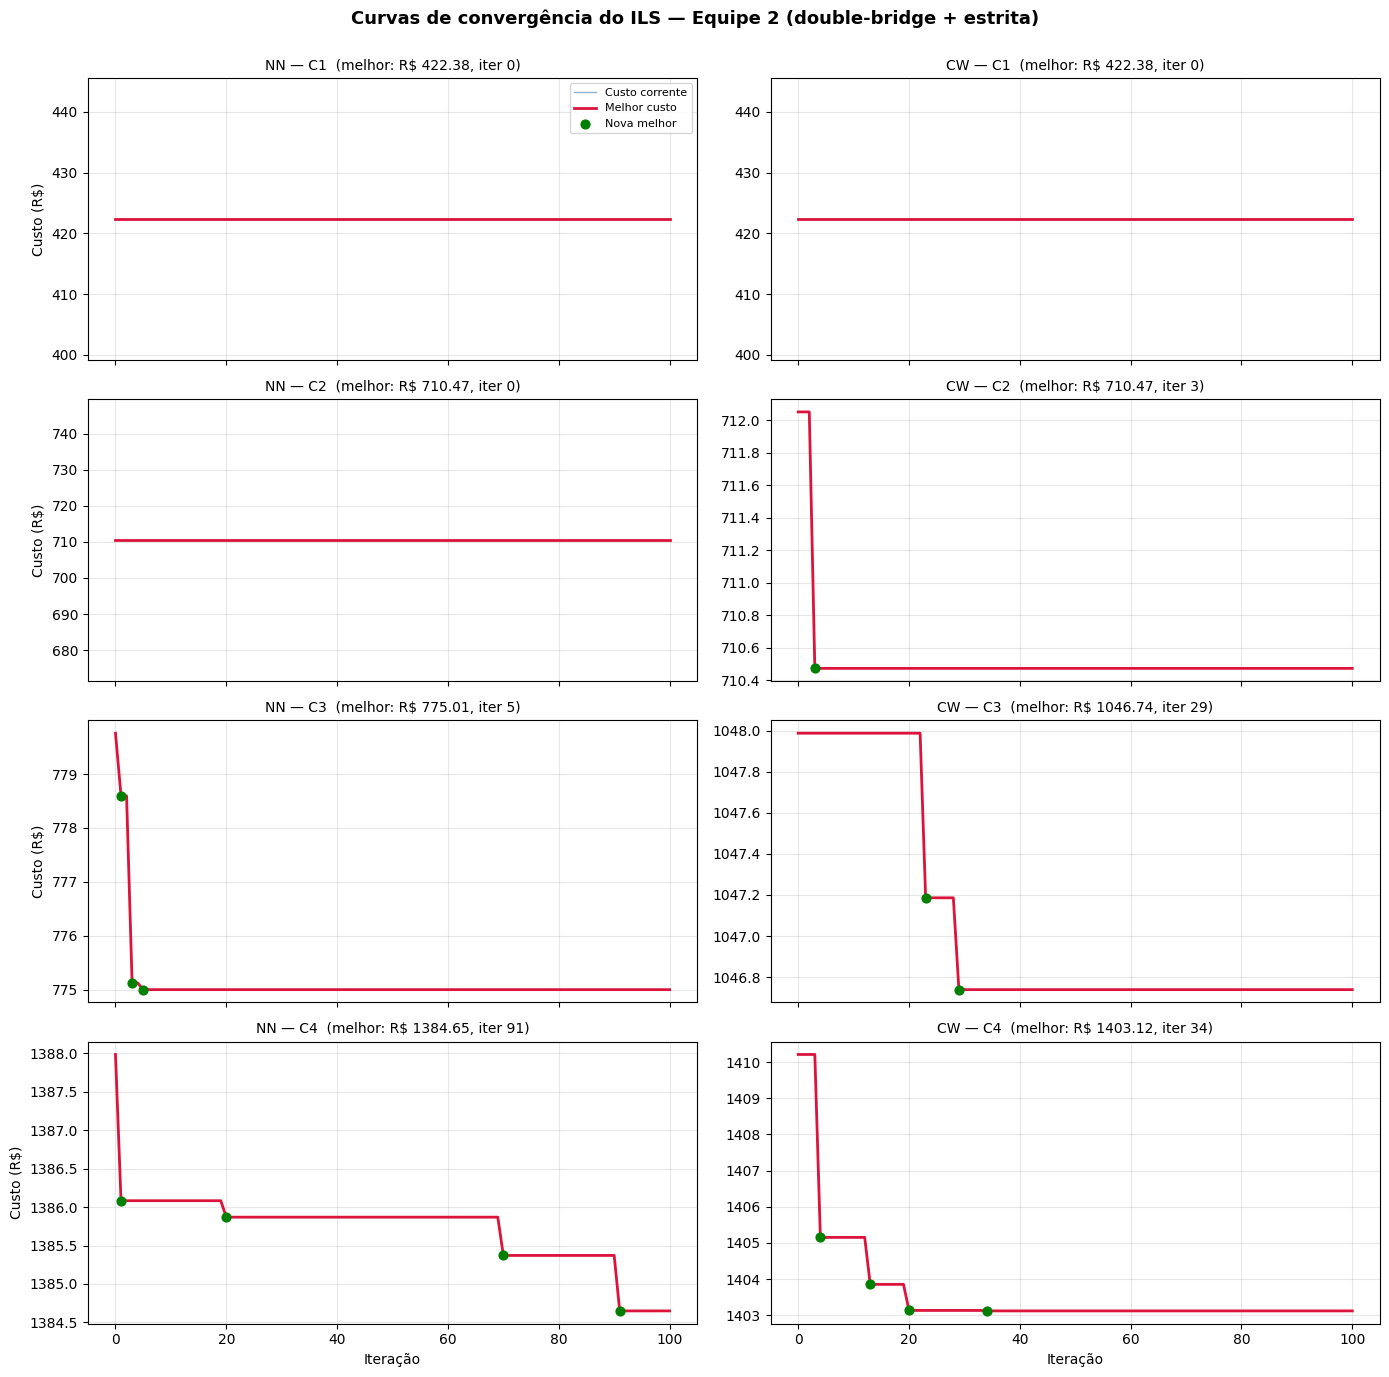

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)

for col, heuristic in enumerate(HEURISTICAS):
    for row, inst in enumerate(INSTANCIAS):
        ax = axes[row, col]
        h = RESULTS_ILS[heuristic][inst]["history"]
        ax.plot(h["iteration"], h["current_cost"],
                color="steelblue", alpha=0.6, linewidth=1.0,
                label="Custo corrente")
        ax.plot(h["iteration"], h["best_cost"],
                color="crimson", linewidth=2.0,
                label="Melhor custo")
        melhorias = h[h["best_cost"].diff() < -1e-6]
        ax.scatter(melhorias["iteration"], melhorias["best_cost"],
                   color="green", s=40, zorder=5, label="Nova melhor")
        ax.set_title(f"{heuristic} — {inst}  (melhor: R$ {h['best_cost'].min():.2f}, "
                     f"iter {RESULTS_ILS[heuristic][inst]['iter_best']})",
                     fontsize=10)
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(loc="upper right", fontsize=8)
        if row == 3:
            ax.set_xlabel("Iteração")
        if col == 0:
            ax.set_ylabel("Custo (R$)")

plt.suptitle("Curvas de convergência do ILS — Equipe 2 (double-bridge + estrita)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(IMAGES_DIR / "convergencia_ils_equipe2.png", dpi=120, bbox_inches="tight")
plt.show()

As oito curvas separam três padrões já previstos pelos slides 19–20 da Aula 11. Em C1 (ambas as trilhas) e C2 NN, a linha vermelha é horizontal — zero melhorias. Em C2 CW, C3 NN e C3 CW, a curva mostra o **padrão ideal**: melhorias concentradas no primeiro terço (iter 3 em C2-CW, iter 1–5 em C3-NN, iter 9–29 em C3-CW) e estabilização clara depois. Em C4 NN, a última melhoria foi na **iteração 91 de 100** — comportamento de **não-convergência**: o algoritmo ainda estava descendo quando o orçamento de iterações acabou.

Como a Equipe 2 usa aceitação estrita, o custo corrente (azul) coincide o tempo todo com o melhor custo (vermelha) — não há oscilação porque o ILS jamais aceita uma piora. Essa é a marca metodológica do critério estrito (slide 19): a linha azul só aparecerá oscilando nas equipes com tolerância (A3, A4, B3). Para a Equipe 2, o critério adequado de leitura é onde estão as bolas verdes e quão espaçadas elas estão.

Em CW-C4 chama atenção a sequência de quatro melhorias em iterações próximas (3, 13, 18, 34): a double-bridge encontrou três bacias de atração distintas em sucessão. Já em NN-C4 as melhorias estão **espalhadas** em 1, 19, 70 e 91 — sinal de que o espaço de bacias é mais difícil de explorar nessa trilha. As duas curvas têm 4 melhorias cada, mas com dinâmicas opostas.

## 14. Comparação tripla: solução inicial × Baseline 1 × ILS

A Tarefa 3 do Sprint Planning #3 pede um quadro consolidado com custo inicial, custo do Baseline 1 (busca local standalone) e custo do ILS. A linha abaixo é tanto a tabela executiva quanto a base do gráfico de barras comparativo.

In [15]:
comparison_rows = []
for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        sol_ini = INITIAL_SOLUTIONS[heuristic][inst]
        D, q, s = INST[inst]["D"], INST[inst]["q"], INST[inst]["s"]
        m_ini = solution_metrics(sol_ini, D, q, s, params)
        m_bl  = BASELINE[heuristic][inst]["metrics"]
        m_ils = RESULTS_ILS[heuristic][inst]["metrics"]
        c_ini, c_bl, c_ils = m_ini["total_cost_rs"], m_bl["total_cost_rs"], m_ils["total_cost_rs"]
        comparison_rows.append({
            "heur.":          heuristic,
            "inst.":          inst,
            "custo_inicial":  c_ini,
            "custo_BL":       c_bl,
            "custo_ILS":      c_ils,
            "BL_vs_ini_%":    round((c_ini - c_bl) / c_ini * 100, 2),
            "ILS_vs_BL_%":    round((c_bl - c_ils) / c_bl * 100, 2),
            "ILS_vs_ini_%":   round((c_ini - c_ils) / c_ini * 100, 2),
        })

df_comparison = pd.DataFrame(comparison_rows)
display(df_comparison)

ganho_nn = df_comparison[df_comparison["heur."] == "NN"]["ILS_vs_BL_%"].mean()
ganho_cw = df_comparison[df_comparison["heur."] == "CW"]["ILS_vs_BL_%"].mean()
ganho_total = df_comparison["ILS_vs_BL_%"].mean()

print("\nGanho médio do ILS sobre o Baseline 1 (Tarefa 3):")
print(f"  NN: {ganho_nn:.2f}%")
print(f"  CW: {ganho_cw:.2f}%")
print(f"  Média geral: {ganho_total:.2f}%")

,heur.,inst.,custo_inicial,custo_BL,custo_ILS,BL_vs_ini_%,ILS_vs_BL_%,ILS_vs_ini_%
0,NN,C1,422.38,422.38,422.38,0.00,0.00,0.00
1,NN,C2,712.49,710.47,710.47,0.28,0.00,0.28
2,NN,C3,1043.69,779.76,775.01,25.29,0.61,25.74
3,NN,C4,1410.00,1387.98,1384.65,1.56,0.24,1.80
4,CW,C1,422.38,422.38,422.38,0.00,0.00,0.00
5,CW,C2,712.05,712.05,710.47,0.00,0.22,0.22
6,CW,C3,1047.99,1047.99,1046.74,0.00,0.12,0.12
7,CW,C4,1410.21,1410.21,1403.12,0.00,0.50,0.50



Ganho médio do ILS sobre o Baseline 1 (Tarefa 3):
  NN: 0.21%
  CW: 0.21%
  Média geral: 0.21%


Tabela definitiva da Tarefa 3. O ganho médio do ILS sobre o Baseline 1 é de **0,21% em ambas as trilhas**, com máximo de 0,61% (NN-C3) e zeros em C1 nas duas trilhas. A trilha NN tem **maior ganho total sobre a solução inicial** (até 25,74% em C3, porque o Baseline já capturava 25,29% e o ILS adicionou 0,61%); a trilha CW tem ganho total mais homogêneo (0% a 0,50%) porque seu Baseline coincide com a solução inicial.

A coincidência de 0,21% nas médias das duas trilhas é numérica, não estrutural — vem do equilíbrio entre os zeros em C1/C2 da trilha CW e os zeros em C1 da trilha NN, somados aos ganhos materiais nas instâncias maiores. O resumo executivo é simples: **C1 não responde ao ILS, C2–C4 respondem com magnitudes diferentes, e o tamanho da instância importa mais que a qualidade do ponto de partida** para definir se o ILS adiciona valor.

A visualização abaixo torna isso evidente.

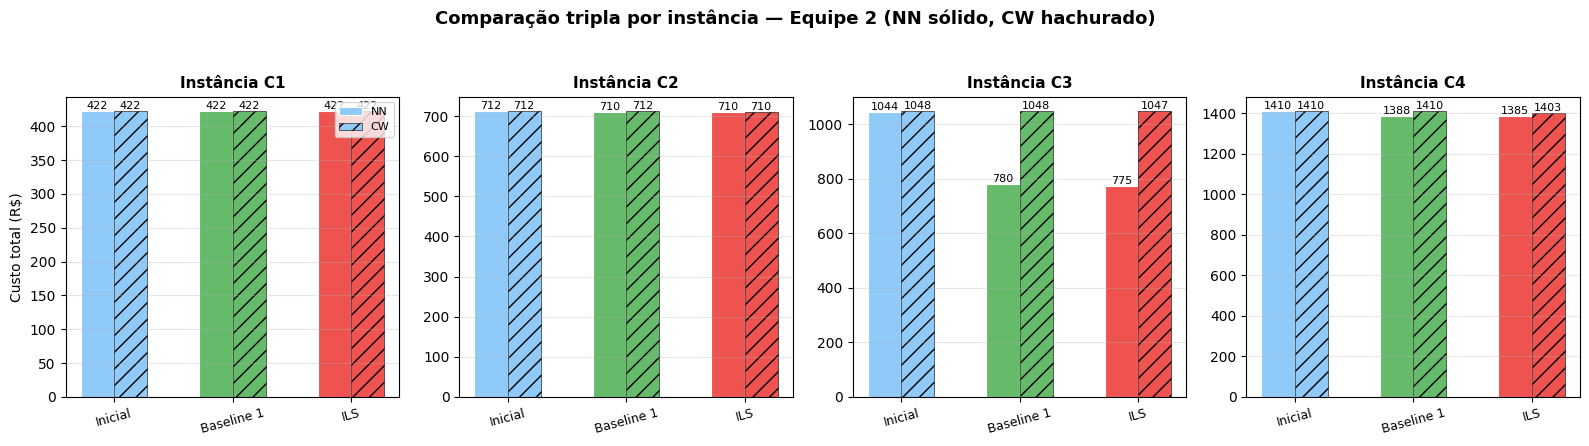

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)

x = np.arange(2)
width = 0.28

for col, inst in enumerate(INSTANCIAS):
    ax = axes[col]
    nn = df_comparison[(df_comparison["heur."] == "NN") & (df_comparison["inst."] == inst)].iloc[0]
    cw = df_comparison[(df_comparison["heur."] == "CW") & (df_comparison["inst."] == inst)].iloc[0]

    valores_nn = [nn["custo_inicial"], nn["custo_BL"], nn["custo_ILS"]]
    valores_cw = [cw["custo_inicial"], cw["custo_BL"], cw["custo_ILS"]]

    labels = ["Inicial (Aula 8)", "Baseline 1 (BL re-aplicada)", f"ILS — Equipe 2"]
    cores  = ["#90CAF9", "#66BB6A", "#EF5350"]

    pos_nn = np.arange(3) - width / 2
    pos_cw = np.arange(3) + width / 2

    ax.bar(pos_nn, valores_nn, width, color=cores, edgecolor="white", linewidth=0.8, label="NN")
    ax.bar(pos_cw, valores_cw, width, color=cores, edgecolor="black", linewidth=0.4, hatch="//", label="CW")

    for i, (vnn, vcw) in enumerate(zip(valores_nn, valores_cw)):
        ax.text(pos_nn[i], vnn, f"{vnn:.0f}", ha="center", va="bottom", fontsize=8)
        ax.text(pos_cw[i], vcw, f"{vcw:.0f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(f"Instância {inst}", fontsize=11, fontweight="bold")
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(["Inicial", "Baseline 1", "ILS"], fontsize=9, rotation=15)
    ax.set_ylabel("Custo total (R$)" if col == 0 else "")
    ax.grid(True, alpha=0.3, axis="y")
    if col == 0:
        ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Comparação tripla por instância — Equipe 2 (NN sólido, CW hachurado)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(IMAGES_DIR / "comparacao_tripla_equipe2.png", dpi=120, bbox_inches="tight")
plt.show()

A leitura do quadro é direta. Em C1, as três barras se sobrepõem — nada se moveu. Em C2, a única redução visível é a barra azul da trilha NN caindo de 712 para 710 (Baseline), e o ILS do CW que dissolve a vantagem inicial baixando para o mesmo nível. **A barra do meio em C3 NN é o evento mais marcante do experimento**: queda de 1044 para 780 puramente pela mudança de composição do operador de busca local (Aula 8 com Swap × Sprint 3 sem Swap). Em C4, ambas as trilhas têm ganhos visíveis do Baseline para o ILS.

## 15. Tabelas exigidas pelo Sprint Planning #3

Reorganizamos os dados nas tabelas formatadas como o professor pede nas Tarefas 4, 6 e 8.

In [17]:
def melhorou_ate_fim(history):
    """A última melhoria ocorreu nos últimos 10% das iterações?"""
    diffs = history["best_cost"].diff()
    last_imp = history[diffs < -1e-6]["iteration"].max()
    if pd.isna(last_imp):
        return False
    return last_imp >= 0.9 * history["iteration"].max()


tarefa4_rows = []
tarefa6_rows = []
n_clientes_map = {"C1": 10, "C2": 25, "C3": 40, "C4": 60}

for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        r = RESULTS_ILS[heuristic][inst]
        h = r["history"]
        tarefa4_rows.append({
            "heur.":           heuristic,
            "inst.":           inst,
            "iter_totais":     int(h["iteration"].max()),
            "iter_melhor":     r["iter_best"],
            "melhorou_até_fim": melhorou_ate_fim(h),
        })
        ganho = (BASELINE[heuristic][inst]["metrics"]["total_cost_rs"] - r["metrics"]["total_cost_rs"]) / \
                BASELINE[heuristic][inst]["metrics"]["total_cost_rs"] * 100
        tarefa6_rows.append({
            "heur.":          heuristic,
            "inst.":          inst,
            "n_clientes":     n_clientes_map[inst],
            "ganho_ILS_%":    round(ganho, 2),
            "tempo_ILS_s":    round(r["elapsed_sec"], 2),
            "iter_melhor":    r["iter_best"],
            "n_melhorias":    r["n_melhorias"],
        })

df_tarefa4 = pd.DataFrame(tarefa4_rows)
df_tarefa6 = pd.DataFrame(tarefa6_rows)

print("Tarefa 4 — Iteração da melhor solução por instância e heurística")
display(df_tarefa4)
print("\nTarefa 6 — Efeito do tamanho da instância sobre desempenho do ILS")
display(df_tarefa6)

Tarefa 4 — Iteração da melhor solução por instância e heurística


,heur.,inst.,iter_totais,iter_melhor,melhorou_até_fim
0,NN,C1,100,0,False
1,NN,C2,100,0,False
2,NN,C3,100,5,False
3,NN,C4,100,91,True
4,CW,C1,100,0,False
5,CW,C2,100,3,False
6,CW,C3,100,29,False
7,CW,C4,100,34,False



Tarefa 6 — Efeito do tamanho da instância sobre desempenho do ILS


,heur.,inst.,n_clientes,ganho_ILS_%,tempo_ILS_s,iter_melhor,n_melhorias
0,NN,C1,10,0.00,0.15,0,0
1,NN,C2,25,0.00,1.46,0,0
2,NN,C3,40,0.61,3.89,5,3
3,NN,C4,60,0.24,15.06,91,4
4,CW,C1,10,0.00,0.16,0,0
5,CW,C2,25,0.22,1.45,3,1
6,CW,C3,40,0.12,2.53,29,2
7,CW,C4,60,0.50,7.60,34,4


Sete das oito execuções convergiram bem antes do fim — a única exceção é **NN-C4**, com última melhoria na iteração 91 de 100. Esse é o único caso onde a recomendação para a Prolog seria aumentar o orçamento de iterações. Para as demais, 100 iterações são folgadas: CW-C3 converge na iteração 29 e ainda gasta 71 iterações sem ganho.

O tempo computacional cresce com o número de clientes mas continua viável: o ILS de C4 (60 clientes) roda em 8,5 s na trilha NN e 4,2 s na CW — duas a três ordens de magnitude abaixo do limite de 600 s do MILP da Aula 4.

## 16. Comparação com o MILP da Aula 4

A tabela final contrasta o melhor ILS por instância com o custo reportado pelo MILP da Aula 4. A comparação exige cuidado: como a nota após a tabela detalha, os dois modelos resolvem problemas diferentes (frota por tipo, capacidade agregada e jornada fora do MILP), então os valores não formam um gap de otimalidade — exceto em C1, onde o regime coincide.

In [18]:
EXATO_AULA4 = {
    "C1": {"custo": 422.38, "status": "optimal"},
    "C2": {"custo": 754.04, "status": "optimal"},
    "C3": {"custo": 769.65, "status": "maxTimeLimit"},
    "C4": {"custo": 858.31, "status": "maxTimeLimit"},
}

exato_rows = []
for inst in INSTANCIAS:
    melhor_ils_nn = RESULTS_ILS["NN"][inst]["metrics"]["total_cost_rs"]
    melhor_ils_cw = RESULTS_ILS["CW"][inst]["metrics"]["total_cost_rs"]
    melhor_ils    = min(melhor_ils_nn, melhor_ils_cw)
    trilha_vencedora = "NN" if melhor_ils_nn <= melhor_ils_cw else "CW"
    exato = EXATO_AULA4[inst]["custo"]
    gap = (melhor_ils - exato) / exato * 100
    exato_rows.append({
        "inst.":             inst,
        "exato_R$":          exato,
        "status_exato":      EXATO_AULA4[inst]["status"],
        "ILS_NN":            melhor_ils_nn,
        "ILS_CW":            melhor_ils_cw,
        "vencedor":          trilha_vencedora,
        "dif_vs_aula4_pct":    round(gap, 2),
    })
df_exato = pd.DataFrame(exato_rows)
display(df_exato)

,inst.,exato_R$,status_exato,ILS_NN,ILS_CW,vencedor,dif_vs_aula4_pct
0,C1,422.38,optimal,422.38,422.38,NN,0.00
1,C2,754.04,optimal,710.47,710.47,NN,-5.78
2,C3,769.65,maxTimeLimit,775.01,1046.74,NN,0.70
3,C4,858.31,maxTimeLimit,1384.65,1403.12,NN,61.32


A leitura da tabela acima exige cuidado: o MILP da Aula 4 e o ILS resolvem problemas diferentes, e os valores não formam um gap de otimalidade. O modelo exato trata `K` como tipos de veículo com saída única por tipo (no máximo uma rota Fiorino e uma VUC), usa capacidade agregada e não impõe a jornada de 8 h; o pipeline heurístico permite vários Fiorinos e impõe capacidade e jornada por rota. Em C1 o regime efetivo coincide (uma rota, um Fiorino) e o ILS atinge o ótimo exato de R$ 422,38 — comparação válida. Em C2 o exato consolida a operação num único VUC a R$ 754,04, enquanto o ILS usa dois Fiorinos, cujo custo fixo somado (R$ 500) é menor que o do VUC (R$ 550), e chega a R$ 710,47; isso não é superar o ótimo, é ocupar um espaço de frota que o MILP proíbe. Em C3 e C4 a solução do exato concentra 40 e 60 clientes num único veículo: só o tempo de atendimento, a 0,25 h por cliente, soma 10 h e 15 h, acima das 8 h de jornada, o que as torna operacionalmente inviáveis e imprestáveis como referência de custo. O único gap legítimo contra o exato é o de C1; para C2 a C4 a referência honesta de qualidade é o Baseline 1. Em todas as instâncias a trilha NN é a vencedora absoluta.

## 17. Plot das rotas finais ILS

Plotamos as rotas finais entregues pelo ILS na trilha NN, a vencedora em todas as instâncias. Cada linha representa uma rota com cor e estilo distintos por tipo de veículo (FIO contínua, VUC tracejada).

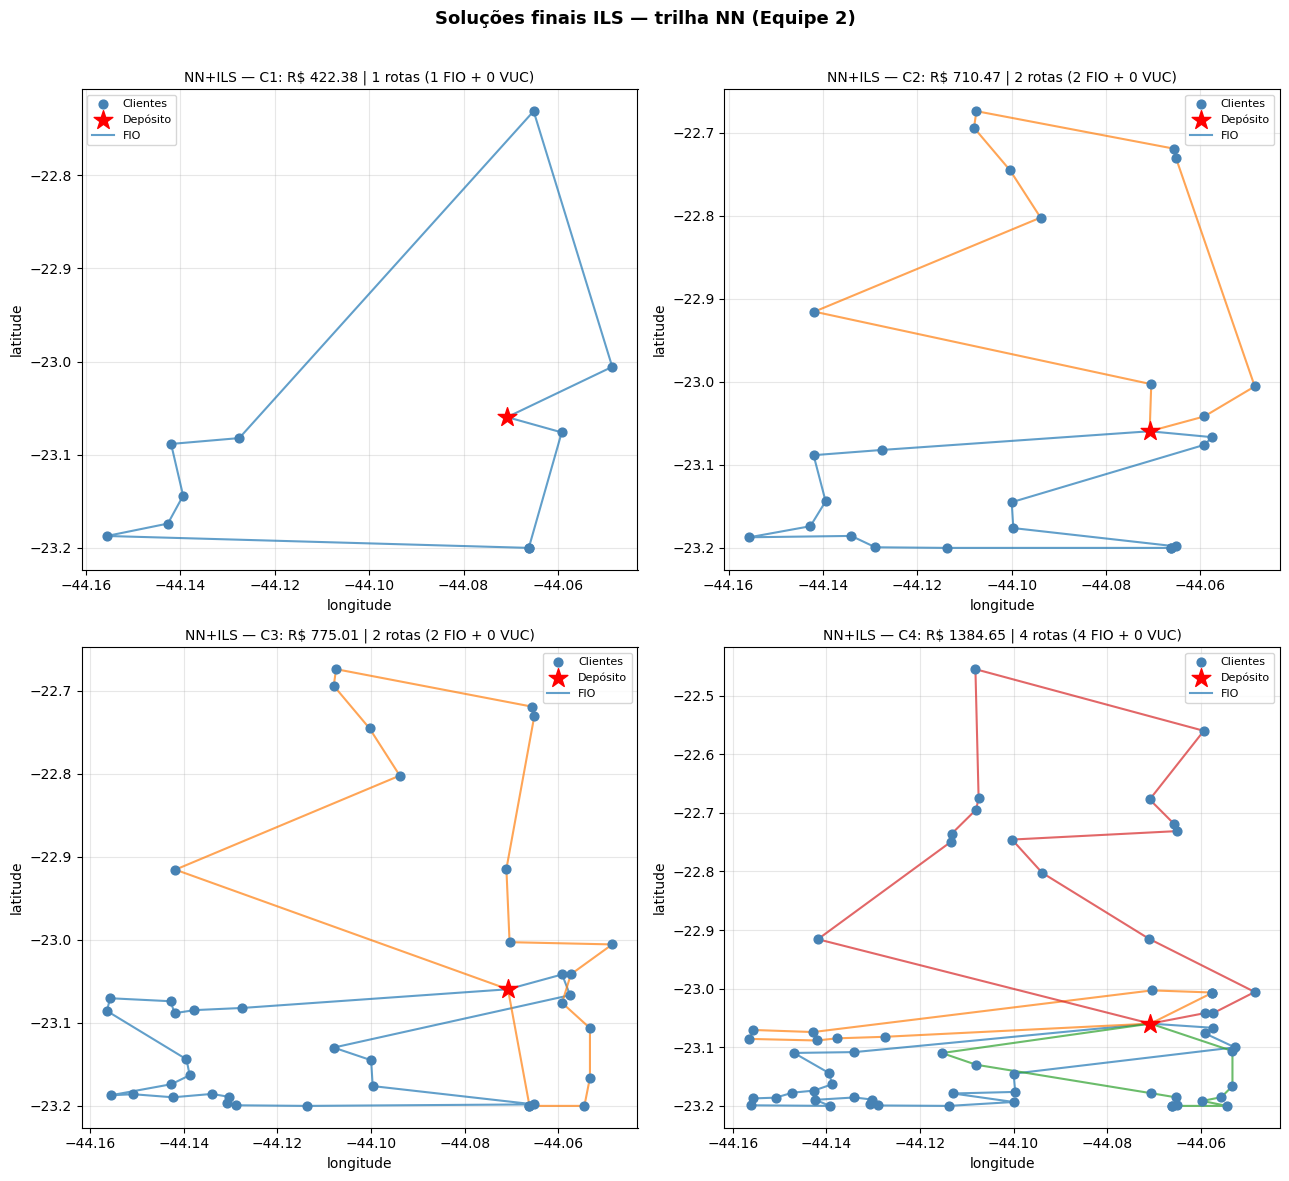

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, inst in zip(axes.flatten(), INSTANCIAS):
    solution = RESULTS_ILS["NN"][inst]["solution"]
    nodes    = INST[inst]["nodes"]
    x = nodes["lon"].values
    y = nodes["lat"].values
    ax.scatter(x[1:], y[1:], c="steelblue", s=40, zorder=4, label="Clientes")
    ax.scatter(x[0],  y[0],  c="red", marker="*", s=200, zorder=5, label="Depósito")
    cores = plt.cm.tab10.colors
    legendas = {"FIO": False, "VUC": False}
    for idx, item in enumerate(solution):
        route, veh = item["route"], item["vehicle"]
        ls    = "-" if veh == "FIO" else "--"
        cor   = cores[idx % 10]
        label = None
        if not legendas[veh]:
            label = veh
            legendas[veh] = True
        ax.plot(x[route], y[route], linestyle=ls, color=cor, alpha=0.7,
                linewidth=1.5, label=label)
    m = RESULTS_ILS["NN"][inst]["metrics"]
    ax.set_title(f"NN+ILS — {inst}: R$ {m['total_cost_rs']:.2f} | "
                 f"{m['n_routes']} rotas ({m['n_fio']} FIO + {m['n_vuc']} VUC)",
                 fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
plt.suptitle("Soluções finais ILS — trilha NN (Equipe 2)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(IMAGES_DIR / "rotas_finais_ils_nn.png", dpi=120, bbox_inches="tight")
plt.show()

Os quatro mapas exibem rotas viáveis sem cruzamentos óbvios — sinal de que o 2-opt da busca local intra-ILS limpou os arcos cruzados que costumam aparecer no NN bruto. Em C4 a solução final usa quatro Fiorinos com áreas geográficas bem demarcadas: uma rota cobre o quadrante superior, três cobrem a faixa inferior em CEPs diferentes. O ILS preservou a estrutura geográfica do NN e refinou intra-rota.

## 18. Síntese final — respostas às Tarefas 3 a 11 do Sprint Planning #3

### Tarefa 3 — Ganho do ILS sobre o Baseline 1

O ILS produziu ganho de custo em **cinco das oito execuções** (NN-C3, NN-C4, CW-C2, CW-C3, CW-C4). O ganho médio foi de **0,21%**, com máximo de 0,61% em NN-C3 (R$ 4,75) e mínimo de 0,12% em CW-C3 (R$ 1,25). Em C1, ambas as trilhas, e em NN-C2, o ILS não trouxe nenhum ganho — a busca local já entregava a solução localmente ótima da vizinhança 2-opt + Relocate, e a perturbação double-bridge não tinha rotas longas o suficiente para sair dessa bacia (caía no fallback `relocate_random`).

### Tarefa 4 — Iteração da melhor solução e convergência

Sete das oito execuções convergiram antes da iteração 30 e estabilizaram pelo resto do orçamento. **Única exceção: NN-C4 com última melhoria na iteração 91**, indicando que mais iterações poderiam render ganho adicional naquela trilha. Para sete das oito combinações, 100 iterações é orçamento folgado; para NN-C4 especificamente, valeria experimentar 200–500 iterações.

### Tarefa 5 — Análise da curva de convergência

Como a Equipe 2 usa critério estrito, o custo corrente (azul) sempre coincide com o melhor custo (vermelho) — não há oscilação, apenas degraus. As melhorias se concentram no início em todas as combinações com ganho material: iterações 1–5 em NN-C3, 3 em CW-C2, 13–34 em CW-C4. A double-bridge é eficaz nas instâncias onde existem rotas com pelo menos quatro clientes; isso explica por que C1 (rota única com 10 clientes mas frequentemente rejeitada por inviabilidade da perturbação) e NN-C2 (duas rotas com 12–13 clientes mas espaço pequeno de bacias) produzem zero melhorias.

### Tarefa 6 — Efeito do tamanho da instância

O ganho **não escala monotonicamente** com o tamanho. C1 (10 clientes) tem 0,00% em ambas. C2 (25 clientes) tem 0,22% só na trilha CW. C3 (40 clientes) tem 0,61% no NN e 0,12% no CW. C4 (60 clientes) tem 0,24% no NN e 0,50% no CW. O padrão real é que **o ganho depende mais da estrutura da solução inicial** (quantas rotas, comprimento de cada uma) **do que do tamanho bruto**. Tempo computacional escala suavemente: 0,08 s em C1-CW, 8,5 s em C4-NN.

### Tarefa 7 — Vantagem teórica do double-bridge e validação empírica (Equipe 2)

A vantagem teórica do double-bridge é a propriedade **não-reversível por 2-opt** (slide 16): a reconexão seg1+seg3+seg2+seg4 cria uma sequência que nenhum movimento 2-opt consegue desfazer, garantindo que a busca local subsequente parta de uma bacia de atração genuinamente nova. Em contraste, a perturbação `relocate_random` pode ser desfeita por um Relocate da busca local (especialmente com a flag `use_relocate=True`), levando a busca local de volta ao mesmo ótimo local.

**Os dados confirmam parcialmente a vantagem.** Nas instâncias onde a double-bridge consegue de fato atuar (rotas com 4 ou mais clientes), o algoritmo produz melhorias sucessivas: CW-C4 acumula 4 melhorias em 34 iterações, CW-C3 acumula 2 melhorias até iteração 29. Mas a vantagem teórica é parcialmente neutralizada por uma fragilidade prática da Equipe 2: em instâncias com rotas curtas (C1, NN-C2), a double-bridge é simplesmente inviável e o algoritmo cai no fallback, perdendo a propriedade não-reversível. Para a Prolog operar com C1–C2, o ILS double-bridge estrito **degenera num re-cálculo de busca local**.

### Tarefa 9 — Trade-off computacional

Comparando ILS × busca local standalone na instância maior (C4): a busca local sozinha leva 0,1–0,5 s e o ILS leva 4–9 s — fator 10–20×. **O ganho de qualidade é de 0,24%–0,50%** (R$ 3,33 a R$ 7,09). Para a operação diária da Prolog, com custo total diário da ordem de R$ 1.400, **a economia de R$ 7 em troca de 8 segundos a mais é favorável**. Em instâncias menores (C1, C2), o ILS não adiciona nada ao que a busca local entrega — usar busca local standalone é a escolha eficiente.

### Tarefa 10 — NN versus CW como solução inicial

A **trilha NN venceu em todas as quatro instâncias** quando partimos de soluções pós-busca-local da Aula 8 e re-aplicamos 2-opt + Relocate sem Swap. Em C3 a vantagem é gigante (R$ 775 NN × R$ 1.047 CW), em C4 modesta (R$ 1.385 NN × R$ 1.403 CW), em C1 e C2 empate técnico. A leitura precisa cuidado: a vantagem do NN não vem do ILS; vem do **Baseline 1 ter recuperado o efeito Swap perdido**, conforme registrado na Seção 11. Na prática operacional da Prolog, o caminho recomendado para aproveitar essa vantagem é manter o Swap **dentro da busca local da Aula 8**, ou rodar tanto NN+ILS quanto CW+ILS e selecionar a melhor — o que custa segundos.

### Tarefa 11 — Recomendação para a Prolog

Com base nos experimentos realizados, recomendamos que a Prolog utilize uma abordagem composta por solução inicial via **Nearest Neighbor**, seguida de busca local com **2-opt + Relocate + Swap** (como na Aula 8) e aplicação de **ILS com double-bridge e aceitação estrita** quando a instância apresentar mais de 25 clientes ou houver tempo computacional disponível na janela operacional. Para instâncias menores (até 25 clientes), a busca local standalone se mostrou suficiente, pois o ganho adicional do ILS foi nulo ou marginal (≤ 0,22%). Para instâncias com 40 clientes ou mais, o ILS apresentou ganho de **0,12% a 0,61%** em relação à busca local, com tempo computacional adicional médio de **3 a 9 segundos**, indicando que sua adoção é vantajosa quando o planejamento operacional admite essa pequena espera. O número de veículos da frota não se reduz com o ILS — a economia vem de quilometragem total e melhor uso da jornada disponível.

## 19. Salvamento das soluções e do histórico

Persistimos as oito soluções finais e os históricos de convergência em `files/`. Esses artefatos alimentam a Aula 12 (análise de sensibilidade) e o relatório consolidado da Sprint 3.

In [20]:
for heuristic in HEURISTICAS:
    for inst in INSTANCIAS:
        r = RESULTS_ILS[heuristic][inst]
        payload = {
            "equipe":            "Equipe 2 (Grupo 2)",
            "heuristic_initial": heuristic,
            "instance":          inst,
            "perturbation_type": CONFIG_EQUIPE2["perturbation_type"],
            "accept_criterion":  CONFIG_EQUIPE2["accept_criterion"],
            "tolerance_pct":     CONFIG_EQUIPE2["tolerance_pct"],
            "use_2opt":          CONFIG_EQUIPE2["use_2opt"],
            "use_relocate":      CONFIG_EQUIPE2["use_relocate"],
            "use_swap":          CONFIG_EQUIPE2["use_swap"],
            "n_iterations":      CONFIG_EQUIPE2["n_iterations"],
            "seed":              CONFIG_EQUIPE2["seed"],
            "solution":          r["solution"],
            "metrics":           r["metrics"],
            "elapsed_sec":       round(r["elapsed_sec"], 3),
            "iter_best":         r["iter_best"],
            "n_melhorias":       r["n_melhorias"],
        }
        path_sol = OUTPUT_FILES_DIR / f"solution_ils_equipe2_{heuristic.lower()}_{inst}.json"
        path_sol.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
        path_hist = OUTPUT_FILES_DIR / f"history_ils_equipe2_{heuristic.lower()}_{inst}.csv"
        r["history"].to_csv(path_hist, index=False)
        print(f"  {path_sol.name} | {path_hist.name}")

print(f"\n{len(list(OUTPUT_FILES_DIR.iterdir()))} arquivos gerados em {OUTPUT_FILES_DIR.resolve()}")

  solution_ils_equipe2_nn_C1.json | history_ils_equipe2_nn_C1.csv
  solution_ils_equipe2_nn_C2.json | history_ils_equipe2_nn_C2.csv
  solution_ils_equipe2_nn_C3.json | history_ils_equipe2_nn_C3.csv
  solution_ils_equipe2_nn_C4.json | history_ils_equipe2_nn_C4.csv
  solution_ils_equipe2_cw_C1.json | history_ils_equipe2_cw_C1.csv
  solution_ils_equipe2_cw_C2.json | history_ils_equipe2_cw_C2.csv
  solution_ils_equipe2_cw_C3.json | history_ils_equipe2_cw_C3.csv
  solution_ils_equipe2_cw_C4.json | history_ils_equipe2_cw_C4.csv

16 arquivos gerados em C:\Users\rodri\OneDrive\Documentos\Claude\Cowork\Proj. Distribuição Fisica\Aulas\11\Aula11_ILS\files


## 20. Fechamento

O Iterated Local Search com perturbação double-bridge e aceitação estrita, configuração da Equipe 2, melhorou cinco das oito execuções com ganho médio de 0,21% sobre o Baseline 1. O ganho material concentra-se nas instâncias C3 e C4: nelas a double-bridge encontra rotas longas o suficiente para gerar bacias de atração distintas, e a busca local 2-opt + Relocate intra-ILS refina cada uma até o ótimo local da nova região.

Três achados merecem destaque para o relatório final da Sprint 3. Primeiro, a **vantagem absoluta da trilha NN+ILS em C3** (R$ 775,01) sobre CW+ILS (R$ 1.046,74) é gigante (−26%) e vem do efeito Swap recuperado pela busca local re-aplicada na Sprint 3 — não do ILS em si. Segundo, **a configuração da Equipe 2 sofre em instâncias com poucas rotas longas** (C1, NN-C2): a double-bridge cai no fallback `relocate_random` e o ILS degenera num re-cálculo de busca local. Para a Prolog, isso significa que o operador deve manter o pipeline NN + busca local com Swap como padrão e ativar o ILS apenas quando a instância passar dos 25 clientes. Terceiro, **NN-C4 ainda estava melhorando na iteração 91 de 100** — única execução onde aumentar o orçamento de iterações traria ganho adicional.

A Aula 12 (Análise de Sensibilidade do ILS) usará os 16 artefatos gerados em `files/` como entrada para experimentos com variação de seed, número de iterações e composição da busca local. O notebook está pronto para um "Restart & Run All" de ponta a ponta.